# 01 — Fine-tuning con Unsloth/LoRA

**Proyecto:** DMC Institute — Clasificador de leads con fine-tuning supervisado  
**Modelo:** Qwen2.5-7B-Instruct + LoRA rank=16 (Unsloth)  
**Entorno recomendado:** Google Colab A100 (40GB) o T4 (16GB con 4-bit)

---

**Estructura del notebook:**
1. Setup e instalación (Unsloth, TRL, PEFT)
2. Baseline: demo del modelo pre-entrenado sin fine-tuning
3. Aplicar LoRA y cargar dataset de 200 ejemplos DMC
4. Entrenamiento con SFTTrainer
5. Comparativa cuantitativa base vs fine-tuned
6. Exportar adapter LoRA para el Plan D

---
## 📦 Task 1: Setup e Instalación

In [1]:
# Celda 0: Instalación (solo en Colab)
import subprocess, sys
pkgs = [
    "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git",
    "trl>=0.8.6", "datasets>=2.18.0", "peft>=0.10.0",
    "transformers>=4.40.0", "accelerate>=0.28.0", "bitsandbytes>=0.43.0",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✅ Unsloth y dependencias instaladas")

✅ Unsloth y dependencias instaladas


In [2]:
# Celda 1: Entorno
import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
if torch.cuda.is_available():
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
# T4 (16GB): OK para Qwen2.5-7B en 4-bit
# A100 (40GB): OK para Qwen2.5-7B en 4-bit o 8-bit

GPU: Tesla T4
VRAM: 15.6 GB


---
## 📊 Task 2: Demo del Modelo BASE (Pre-training Baseline)

In [3]:
# Celda 2: Cargar modelo base para baseline
from unsloth import FastLanguageModel
import torch

MAX_SEQ_LENGTH = 2048
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,         # auto-detect
    load_in_4bit=True,
)
print(f"✅ Modelo base cargado")
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.1: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.34k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-7B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
✅ Modelo base cargado
Parámetros totales: 4,352,972,288


In [4]:
# Celda 3: Guardar respuestas del modelo BASE para comparativa posterior
import json

FastLanguageModel.for_inference(model)

SYSTEM = (
    "Eres un clasificador de leads para DMC Institute. "
    "Dado un mensaje de usuario, responde SOLO con JSON: "
    '{"motivation": "growth|salary|company_requirement|academic|undefined", '
    '"score": "hot|warm|cold", "recommended_program": "<slug>", "justification": "<1 oración>"}'
)

TEST_CASES = [
    ("Mi empresa me pidió que me certifique en Azure.", "company_requirement", "hot"),
    ("Quiero ganar más dinero aprendiendo datos.", "salary", "warm"),
    ("Hola, ¿qué cursos tienen?", "undefined", "cold"),
    ("Quiero cambiar de carrera a data analyst.", "growth", "warm"),
    ("¿Cuánto dura el diploma de data science?", "undefined", "warm"),
]

base_results = []
for msg, gt_motivation, gt_score in TEST_CASES:
    messages = [{"role": "system", "content": SYSTEM}, {"role": "user", "content": msg}]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    outputs = model.generate(input_ids=inputs, max_new_tokens=150, temperature=0.1, do_sample=True)
    response = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)

    try:
        parsed = json.loads(response.strip())
        got_motivation = parsed.get("motivation", "error")
        got_score = parsed.get("score", "error")
        valid_json = True
    except json.JSONDecodeError:
        got_motivation = "json_error"
        got_score = "json_error"
        valid_json = False

    base_results.append({
        "msg": msg, "gt_motivation": gt_motivation, "gt_score": gt_score,
        "got_motivation": got_motivation, "got_score": got_score, "valid_json": valid_json,
    })
    print(f"Input:  {msg}")
    print(f"Output: {response[:120]}")
    print()

print("=== BASELINE (sin fine-tuning) ===")
print(f"JSON válido: {sum(r['valid_json'] for r in base_results)}/{len(base_results)}")
print(f"Motivación correcta: {sum(r['got_motivation']==r['gt_motivation'] for r in base_results)}/{len(base_results)}")
print(f"Score correcto: {sum(r['got_score']==r['gt_score'] for r in base_results)}/{len(base_results)}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_

Input:  Mi empresa me pidió que me certifique en Azure.
Output: {"motivation": "company_requirement", "score": "warm", "recommended_program": "azure-certification", "justification": "L



/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Input:  Quiero ganar más dinero aprendiendo datos.
Output: {"motivation": "salary|growth", "score": "warm", "recommended_program": "data_science_intensive", "justification": "El u



Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Input:  Hola, ¿qué cursos tienen?
Output: {"motivation": "undefined", "score": "cold", "recommended_program": "", "justification": "El mensaje no indica interés e



Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Input:  Quiero cambiar de carrera a data analyst.
Output: {"motivation": "academic", "score": "warm", "recommended_program": "data-analytics-bootcamp", "justification": "El usuar

Input:  ¿Cuánto dura el diploma de data science?
Output: {"motivation": "undefined", "score": "cold", "recommended_program": "data-science-diploma", "justification": "La pregunt

=== BASELINE (sin fine-tuning) ===
JSON válido: 5/5
Motivación correcta: 3/5
Score correcto: 3/5


---
## 🔧 Task 3 & 4: Aplicar LoRA y Entrenar

In [5]:
# Celda 4: Configurar LoRA
FastLanguageModel.for_training(model)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"✅ LoRA aplicado | Parámetros entrenables: {trainable:,} ({100*trainable/total:.2f}%)")

Unsloth 2026.6.1 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


✅ LoRA aplicado | Parámetros entrenables: 40,370,176 (0.92%)


In [9]:
# Celda 5: Preparar dataset para SFTTrainer
# Subir dmc_leads.json a /content/ antes de ejecutar esta celda
# O cargarlo desde Google Drive: from google.colab import drive; drive.mount('/content/drive')
import json
from datasets import Dataset

with open("dataset/dmc_leads.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

def format_example(example):
    return {"text": tokenizer.apply_chat_template(
        example["messages"], tokenize=False, add_generation_prompt=False
    )}

records = [{"messages": c["messages"]} for c in raw["conversations"]]
ds = Dataset.from_list(records).map(format_example)
print(f"✅ Dataset listo: {len(ds)} ejemplos")
print("Ejemplo formateado (primeros 300 chars):")
print(ds[0]["text"][:300])

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

✅ Dataset listo: 200 ejemplos
Ejemplo formateado (primeros 300 chars):
<|im_start|>system
Eres un clasificador de leads para DMC Institute. Dado un mensaje de usuario, responde SOLO con JSON: {"motivation": "growth|salary|company_requirement|academic|undefined", "score": "hot|warm|cold", "recommended_program": "<slug>", "justification": "<1 oración>"}<|im_end|>
<|im_st


In [11]:
# Celda 6: Entrenar
import os
from trl import SFTTrainer, SFTConfig  # ← add SFTConfig here
from unsloth import is_bfloat16_supported

os.makedirs("outputs", exist_ok=True)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=ds,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    args=SFTConfig(
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        num_train_epochs=3,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=42,
        output_dir="outputs",
        report_to="none",
    ),
)
stats = trainer.train()
print(f"✅ Entrenamiento completo")
print(f"Tiempo: {stats.metrics['train_runtime']:.0f}s | Loss final: {stats.metrics['train_loss']:.4f}")
# Loss debe bajar de ~2.0 a <0.5. Si no, aumentar num_train_epochs a 5.

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/200 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 200 | Num Epochs = 3 | Total steps = 39
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,0.141663
20,0.066783
30,0.041426


✅ Entrenamiento completo
Tiempo: 355s | Loss final: 0.0721


---
## 📈 Task 5: Comparativa Base vs Fine-tuned

In [12]:
# Celda 7: Evaluar modelo fine-tuned con los mismos TEST_CASES
FastLanguageModel.for_inference(model)

ft_results = []
for msg, gt_motivation, gt_score in TEST_CASES:
    messages = [{"role": "system", "content": SYSTEM}, {"role": "user", "content": msg}]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    outputs = model.generate(input_ids=inputs, max_new_tokens=150, temperature=0.1, do_sample=True)
    response = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)

    try:
        parsed = json.loads(response.strip())
        got_motivation = parsed.get("motivation", "error")
        got_score = parsed.get("score", "error")
        valid_json = True
    except json.JSONDecodeError:
        got_motivation = "json_error"
        got_score = "json_error"
        valid_json = False

    ft_results.append({
        "msg": msg, "gt_motivation": gt_motivation, "gt_score": gt_score,
        "got_motivation": got_motivation, "got_score": got_score, "valid_json": valid_json,
    })
    print(f"Input:  {msg}")
    print(f"Output: {response[:120]}")
    print()

Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=1

Input:  Mi empresa me pidió que me certifique en Azure.
Output: {"motivation": "company_requirement", "score": "hot", "recommended_program": "azure-data-engineering", "justification": 



Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Input:  Quiero ganar más dinero aprendiendo datos.
Output: {"motivation": "salary", "score": "warm", "recommended_program": "diploma-data-analyst", "justification": "Motivación sa



Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Input:  Hola, ¿qué cursos tienen?
Output: {"motivation": "undefined", "score": "cold", "recommended_program": "membresia-datapro", "justification": "Motivación un



Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Input:  Quiero cambiar de carrera a data analyst.
Output: {"motivation": "growth", "score": "warm", "recommended_program": "diploma-data-analyst", "justification": "Motivación gr

Input:  ¿Cuánto dura el diploma de data science?
Output: {"motivation": "undefined", "score": "warm", "recommended_program": "diploma-data-scientist", "justification": "Motivaci



Métrica                           Base   Fine-tuned
JSON válido                       100%         100%  (+0%)
Motivación correcta                60%         100%  (+40%)
Score correcto                     60%         100%  (+40%)


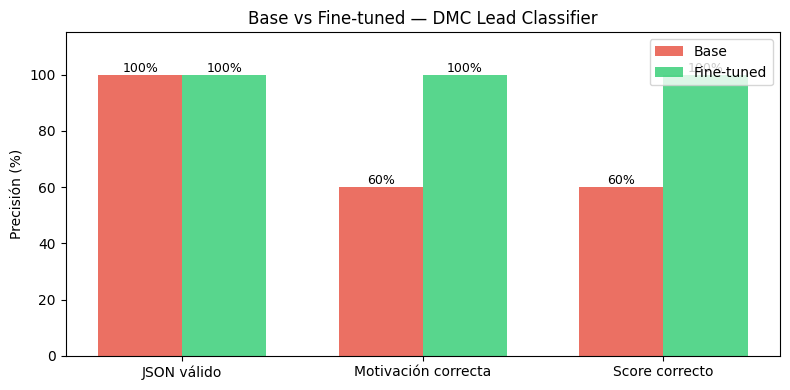

✅ Gráfica guardada en outputs/base_vs_finetuned.png


In [13]:
# Celda 8: Tabla comparativa BASE vs FINE-TUNED
import matplotlib.pyplot as plt
import numpy as np

n = len(TEST_CASES)
metrics = {
    "JSON válido": (
        sum(r["valid_json"] for r in base_results) / n * 100,
        sum(r["valid_json"] for r in ft_results) / n * 100,
    ),
    "Motivación correcta": (
        sum(r["got_motivation"] == r["gt_motivation"] for r in base_results) / n * 100,
        sum(r["got_motivation"] == r["gt_motivation"] for r in ft_results) / n * 100,
    ),
    "Score correcto": (
        sum(r["got_score"] == r["gt_score"] for r in base_results) / n * 100,
        sum(r["got_score"] == r["gt_score"] for r in ft_results) / n * 100,
    ),
}

print("=" * 55)
print(f"{'Métrica':<25} {'Base':>12} {'Fine-tuned':>12}")
print("=" * 55)
for metric, (base_val, ft_val) in metrics.items():
    delta = ft_val - base_val
    print(f"{metric:<25} {base_val:>11.0f}% {ft_val:>11.0f}%  (+{delta:.0f}%)")
print("=" * 55)

# Gráfico de barras
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(metrics))
w = 0.35
bars_base = ax.bar(x - w/2, [v[0] for v in metrics.values()], w, label="Base", color="#e74c3c", alpha=0.8)
bars_ft = ax.bar(x + w/2, [v[1] for v in metrics.values()], w, label="Fine-tuned", color="#2ecc71", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(list(metrics.keys()))
ax.set_ylabel("Precisión (%)")
ax.set_ylim(0, 115)
ax.set_title("Base vs Fine-tuned — DMC Lead Classifier")
ax.legend()
for bar in bars_base:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{bar.get_height():.0f}%", ha="center", fontsize=9)
for bar in bars_ft:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{bar.get_height():.0f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/base_vs_finetuned.png", dpi=150)
plt.show()
print("✅ Gráfica guardada en outputs/base_vs_finetuned.png")

---
## 💾 Task 6: Exportar Adapter LoRA

In [14]:
# Celda 9: Exportar adapter LoRA para usar en Plan D
import os
os.makedirs("outputs/lora_adapter", exist_ok=True)
model.save_pretrained("outputs/lora_adapter")
tokenizer.save_pretrained("outputs/lora_adapter")
print(f"✅ Adapter LoRA exportado en outputs/lora_adapter/")
print(f"Archivos: {os.listdir('outputs/lora_adapter')}")

Unsloth: Restored added_tokens_decoder metadata in outputs/lora_adapter/tokenizer_config.json.


✅ Adapter LoRA exportado en outputs/lora_adapter/
Archivos: ['chat_template.jinja', 'adapter_config.json', 'tokenizer.json', 'adapter_model.safetensors', 'tokenizer_config.json', 'README.md']


In [15]:
# Celda 10: Publicar en HuggingFace Hub (requiere HF_TOKEN en Colab Secrets)
import os
HF_TOKEN = os.getenv("HF_TOKEN")
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN)
    REPO = "sebastianperudev2001/dmc-lead-classifier-qwen25-7b-lora"
    model.push_to_hub(REPO)
    tokenizer.push_to_hub(REPO)
    print(f"✅ Publicado: https://huggingface.co/{REPO}")
else:
    print("⚠️  HF_TOKEN no configurado. Adapter disponible solo localmente.")

⚠️  HF_TOKEN no configurado. Adapter disponible solo localmente.
